In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import glob
from pathlib import Path
import json

# Set style for matplotlib
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 24

In [14]:
soln_nums = [
    1, 2, 3, 4
]
titles = [
    'Plane waves', 'Radial waves', 'Hopf fibration', 'Random solution'
]

In [15]:
# runs = [
#     os.path.join('experiments', str(x)) for x in range(826, 906)
# ]

original_runs = [
    os.path.join('experiments', str(x)) for x in range(1522, 1562)
]

runs = [
    os.path.join('experiments', str(x)) for x in range(1562, 1582)
]

for run in original_runs:
    hparams = json.load(open(os.path.join(run, 'hparams.json')))
    if hparams['add_bc'] and not hparams['do_masking']:
        continue
    else:
        runs.append(run)

assert len(runs) == 40, len(runs)

In [16]:
exps = {
    1: [],
    2: [],
    3: [],
    4: []
}

settings = {
    'add_bc': False,
    'use_cpu': False
}

for run in runs:
    keep_run = True
    hparams = json.load(open(os.path.join(run, 'hparams.json')))
    for k, v in settings.items():
        if hparams[k] != v:
            keep_run = False
            break
    if keep_run:
        exps[hparams['soln']].append(run)

In [17]:
def interpolate_runs(dfs, n_points=1000, max_time=None, time_already_cum=False, log=False):
    
    if log:
        max_time = np.exp(max_time)
    
    if not time_already_cum:
        cumtimes = [df['training_time'].cumsum().values for df in dfs]
    else:
        cumtimes = [df['training_time'] for df in dfs]
    errors   = [df['rel_l2_error'].values * 100     for df in dfs]

    t_min = max(ct[0] for ct in cumtimes)  # latest start across seeds

    if max_time is not None:
        t_max = max_time
    else:
        t_max = min(ct[-1] for ct in cumtimes)  # earliest end (inner range)

    x = np.linspace(t_min, t_max, n_points)

    # Each seed may have a different number of epochs within [t_min, t_max]
    # np.interp handles this naturally — it uses however many points each
    # seed has up to t_max, and clamps to the last known value beyond it
    interp_errors = np.stack([
        np.interp(x, ct, err)
        for ct, err in zip(cumtimes, errors)
    ])  # shape: (n_runs, n_points)

    n_runs = len(dfs)
    
    if log:
        x = np.log(x)
        interp_errors = np.log(interp_errors)

    y = interp_errors.mean(axis=0)
    y_err = interp_errors.std(axis=0) / np.sqrt(n_runs)

    return x, y, y_err

/var/folders/54/ctkh4lg97kd4x1fv3qzrpd3c0000gp/T/ipykernel_76879/2600602275.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.0)


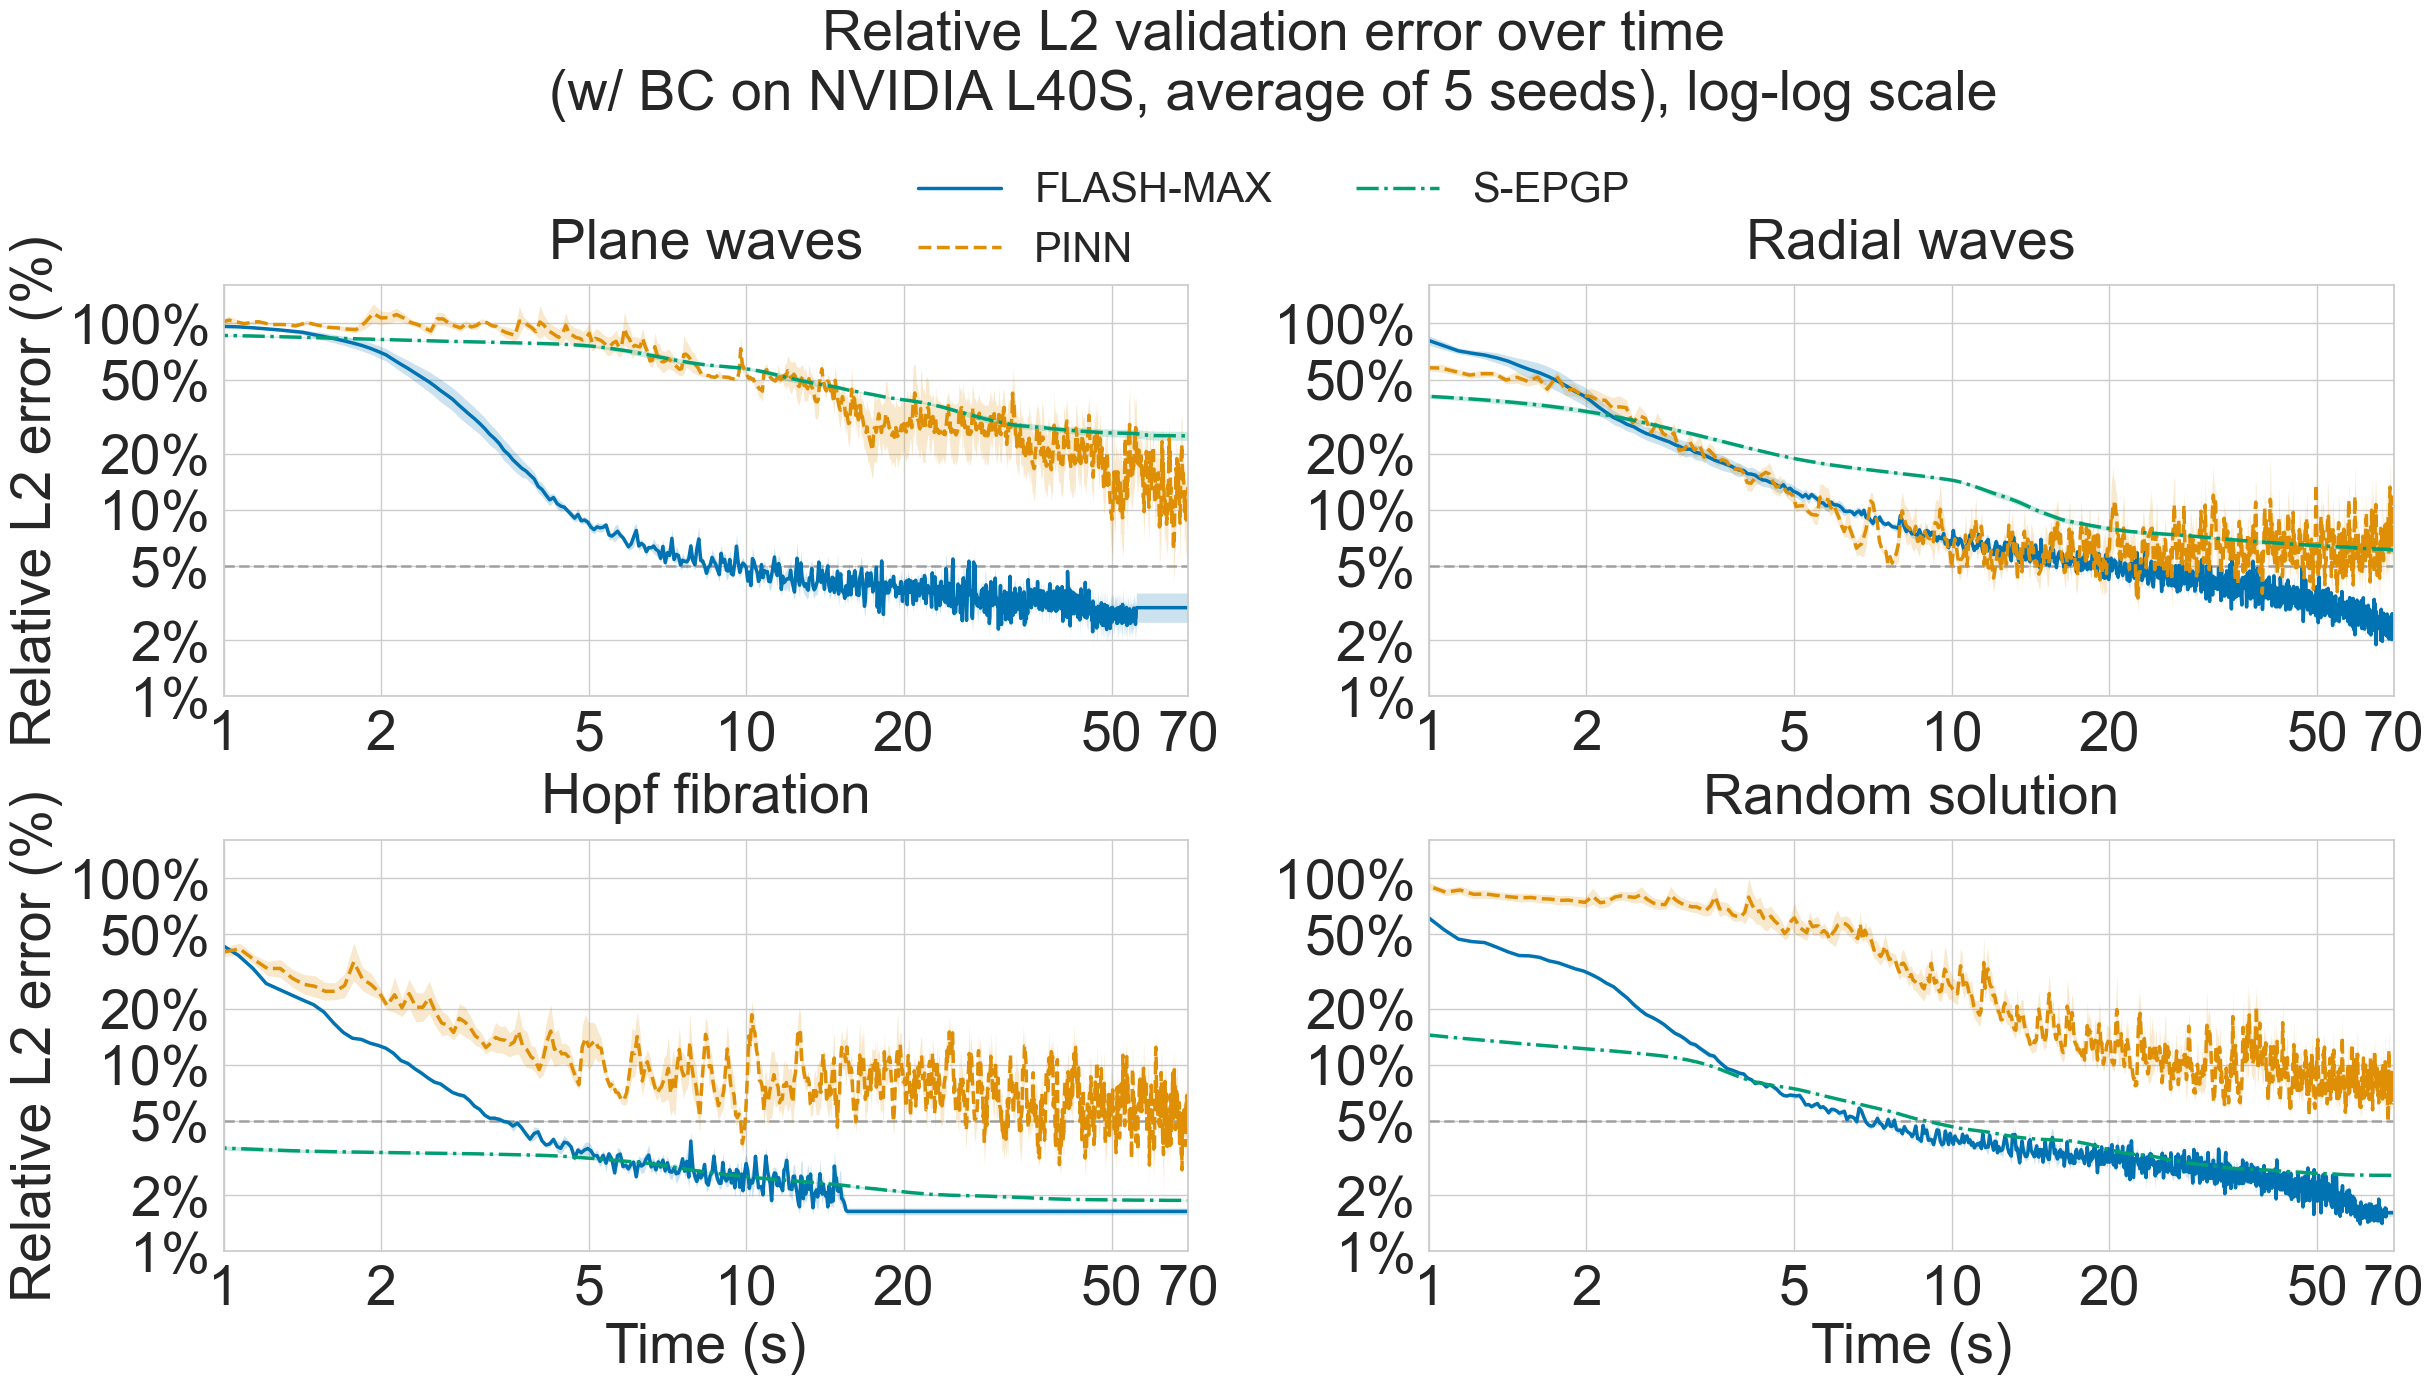

In [18]:
fs = 40
lfs = 30

log = True

max_time = 70
max_err = 160

if log:
    ytick_vals = np.array([1, 2, 5, 10, 20, 50, 100])
    xtick_vals = np.array([1, 2, 5, 10, 20, 50, 70])
    yticks = np.log(ytick_vals)
    xticks = np.log(xtick_vals)
    max_time = np.log(max_time)
    max_err = np.log(max_err)
else:
    ytick_vals = np.array([0, 20, 40, 60, 80, 100, 120, 140, 160])
    xtick_vals = np.array([0, 10, 20, 30, 40, 50, 60, 70])
    yticks = ytick_vals
    xticks = xtick_vals

plt.rcParams.update({
    'font.size': fs,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': lfs,
    'legend.title_fontsize': lfs,
    'figure.titlesize': fs
})

fig = plt.figure(figsize=(28, 28 * (max_err / max_time) * 0.75 / 2))  # taller than wide panels
gs = gridspec.GridSpec(2, 2, width_ratios=[0.5, 0.5], hspace=0.35, wspace=0.25)

colors = sns.color_palette("colorblind", 4)
line_styles = ['-', '--', '-.', ':']

axes = []

for i, (soln_num, title) in enumerate(zip(soln_nums, titles)):
    row, col = divmod(i, 2)
    ax = fig.add_subplot(gs[row, col])
    axes.append(ax)

    exps_soln_num = exps[soln_num]
    logs = [
        pd.read_csv(os.path.join(exp, 'log.tsv'), sep='\t')
        for exp in exps_soln_num
    ]

    if   soln_num == 1: pinn_soln_name = 'planewave'
    elif soln_num == 2: pinn_soln_name = 'donut'
    elif soln_num == 3: pinn_soln_name = 'hopf'
    elif soln_num == 4: pinn_soln_name = 'random'

    if settings['add_bc']:
        pinn_logs = [
            pd.read_csv(
                os.path.join(
                    'pinn_data', 'maxwell_bdy', pinn_soln_name, f'seed_{j}', 'log.tsv'
                ), sep='\t')
            for j in range(1, 6)
        ]
    
        gp_logs = [
            pd.read_csv(
                os.path.join(
                    'gp_data', 'BDY', 'GP_' + pinn_soln_name, f'GP_BDY_{pinn_soln_name}_seed{j}.tsv'
                ), sep='\t').rename(columns={'time_elapsed': 'training_time', 'best_val_rel_err': 'rel_l2_error'})
            for j in range(1, 6)
        ]
    else:
        pinn_logs = [
            pd.read_csv(
                os.path.join(
                    'pinn_data', 'maxwell_nbdy', pinn_soln_name, f'seed_{j}', 'log.tsv'
                ), sep='\t')
            for j in range(1, 6)
        ]
    
        gp_logs = [
            pd.read_csv(
                os.path.join(
                    'gp_data', 'NBDY', 'GP_' + pinn_soln_name, f'GP_NBDY_{pinn_soln_name}_seed{j}.tsv'
                ), sep='\t').rename(columns={'time_elapsed': 'training_time', 'best_val_rel_err': 'rel_l2_error'})
            for j in range(1, 6)
        ]

    assert len(logs) == 5
    assert len(pinn_logs) == 5
    assert len(gp_logs) == 5

    datas = [
        interpolate_runs(logs,      max_time=max_time, log=log),
        interpolate_runs(pinn_logs, max_time=max_time, time_already_cum=True, log=log),
        interpolate_runs(gp_logs, max_time=max_time, time_already_cum=True, log=log),
    ]
    
    labels = ['FLASH-MAX', 'PINN', 'S-EPGP']

    # Gray reference line at 5%
    thresh = 5 if not log else np.log(5)
    ax.axhline(y=thresh, color='gray', linewidth=2.0, linestyle='--', alpha=0.6, zorder=1)

    for color, line_style, data, label in zip(colors, line_styles, datas, labels):
        x_values, y_smooth, y_std = data
        if log:
            clip_val = np.log(1)
        else:
            clip_val = 0
        ax.fill_between(
            x_values,
            np.clip(y_smooth - y_std, clip_val, max_err),
            np.clip(y_smooth + y_std, clip_val, max_err),
            alpha=0.2, color=color, linewidth=0
        )
        ax.plot(
            x_values,
            np.clip(y_smooth, clip_val, max_err),
            linewidth=2.5,
            color=color,
            linestyle=line_style,
            label=label
        )

    ax.set_title(title, pad=20)
    ax.set_ylim(0, max_err)
    ax.set_xlim(np.log(1) if log else 0, max_time)

    if row == 1:
        ax.set_xlabel("Time (s)")
    else:
        ax.set_xlabel("")

    if col == 0:
        ax.set_ylabel("Relative L2 error (%)")
    else:
        ax.set_ylabel("")

    ax.set_yticks(yticks)  # yticks = np.log([20, 40, ..., 160])
    ax.set_yticklabels([f'{v:.0f}%' for v in ytick_vals])

    ax.set_xticks(xticks)  # xticks = np.log([10, 20, ..., 70])
    ax.set_xticklabels([f'{v:.0f}' for v in xtick_vals])

    # Make the plot area taller than wide via aspect — 'box' keeps axes box fixed
    # ax.set_aspect(max_time / max_err * 0.75, adjustable='box')  # <1 = taller than wide

if log:
    fig.suptitle(
        'Relative L2 validation error over time\n(w/ BC on NVIDIA L40S, average of 5 seeds), log-log scale',
        fontsize=fs, y=1.1
    )
else:
    fig.suptitle(
        'Relative L2 validation error over time\n(w/ BC on NVIDIA L40S, average of 5 seeds)',
        fontsize=fs, y=1.1
    )

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels_,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
    fontsize=lfs,
    frameon=False
)

plt.tight_layout(pad=1.0)
plt.savefig(f"timing_plots_bc_{settings['add_bc']}.pdf", bbox_inches='tight')
plt.show()